#손가락 숫자 모양의 Image 분류

In [1]:
import warnings
warnings.filterwarnings('ignore')

---
#Data 불러오기

In [2]:
#glob
import glob
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
#파일 이름 불러오기(데이터 아님)
train_images= glob.glob("../Data/fingers/train/*.png")

In [4]:
test_images= glob.glob("../Data/fingers/test/*.png")

In [5]:
#file name 확인
train_images[:5]

['../Data/fingers/train/9e3cb712-4679-4e23-bc0f-fc0606e0ca58_5R.png',
 '../Data/fingers/train/93486912-fc61-40f3-bd74-fca8d77fb52f_4R.png',
 '../Data/fingers/train/4490a85e-2a7b-457e-a1ff-c2504980c17a_2L.png',
 '../Data/fingers/train/9e158656-ce8c-471d-9fb4-d342ff6e0d78_3L.png',
 '../Data/fingers/train/5f38e471-44be-442c-879d-f5d0d733821c_3R.png']

In [6]:
test_images[:5]#타겟데이터:4L 파일이름에서 추출해야함

['../Data/fingers/test/ceae20d5-c107-4c79-914e-4162e3d0e9f1_4L.png',
 '../Data/fingers/test/7ba8b54e-5772-496a-962e-5b5adcb724fa_3R.png',
 '../Data/fingers/test/397c5786-3c98-4a44-bae7-93c913d0bd37_1L.png',
 '../Data/fingers/test/16ca9fd4-dbc4-4c09-ba3b-5633aa9e4d5e_2L.png',
 '../Data/fingers/test/c989343b-e77c-4192-afd0-6f3856b78562_4R.png']

In [7]:
#갯수 확인
print(len(train_images))
print(len(test_images))

18000
3600


In [8]:
#train data와 test data 만들기:128*128->32*32로 변경
X_train=[]
X_test=[]
y_train=[]
y_test=[]#파이썬은 리스트

#train data
for image in sorted(train_images):
    # print(image)
    img = Image.open(image)#img=그림/ image=파일이름
    imgResize=img.resize((32,32), Image.Resampling.LANCZOS)#계단 현상/깨짐방지
    X_train.append(imgResize)
    y_train.append(image[-6:-4])

#test data
for image in sorted(test_images):
    # print(image)
    img = Image.open(image)#img=그림/ image=파일이름
    imgResize=img.resize((32,32), Image.Resampling.LANCZOS)#계단 현상/깨짐방지
    X_test.append(imgResize)
    y_test.append(image[-6:-4])

In [9]:
#label Data 확인(그림)
print(y_train[:5])
print(y_test[:5])

['0L', '0L', '2L', '0L', '5L']
['5L', '5L', '3R', '5L', '5L']


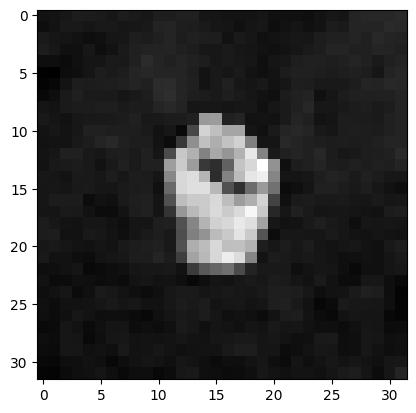

In [10]:
#train의 이미지 확인
plt.imshow(X_train[0],cmap='gray')
plt.show()

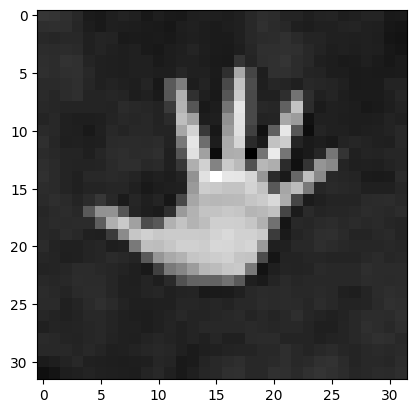

In [11]:
#test의 이미지 확인
plt.imshow(X_test[0],cmap='gray')
plt.show()

----
####numpy 배열로 변경(3차원:페이지 로우 컬럼)

In [12]:
import numpy as np

In [13]:
#train data 만들기
tempData=np.zeros(
18000*32*32,dtype=np.int32
).reshape(18000,32,32)
#0은 검정색,18000개,무조건 1차원=>reshape
#이미지를 각자 불러와 __로 만듦

i=0
for image in X_train:
    img=np.array(image, dtype=np.int32)#2차원 데이터
    tempData[i,:,:] = img
    i+=1

X_train=tempData.copy()#파이썬 

In [14]:
# test data 만들기
tempData=np.zeros(
36000*32*32,dtype=np.int32
).reshape(36000,32,32)

i=0
for image in X_test:
    img=np.array(image, dtype=np.int32)#2차원 데이터
    tempData[i,:,:] = img
    i+=1

X_test= tempData.copy()#파이썬 

In [15]:
tempData.shape#3차원

(36000, 32, 32)

In [16]:
#배열 크기 확인
print(X_train.shape, X_test.shape)

(18000, 32, 32) (36000, 32, 32)


In [17]:
X_train#3차원

array([[[51, 52, 55, ..., 66, 66, 68],
        [48, 52, 56, ..., 64, 68, 67],
        [57, 54, 53, ..., 67, 65, 63],
        ...,
        [47, 46, 54, ..., 51, 48, 50],
        [44, 43, 48, ..., 50, 54, 55],
        [42, 41, 46, ..., 47, 54, 64]],

       [[48, 44, 45, ..., 56, 54, 54],
        [43, 46, 44, ..., 54, 49, 50],
        [52, 45, 43, ..., 52, 50, 51],
        ...,
        [55, 58, 53, ..., 49, 49, 52],
        [65, 64, 58, ..., 52, 54, 50],
        [68, 62, 58, ..., 55, 56, 54]],

       [[57, 59, 44, ..., 58, 52, 51],
        [55, 55, 47, ..., 58, 58, 52],
        [48, 47, 51, ..., 52, 52, 53],
        ...,
        [39, 42, 40, ..., 52, 48, 52],
        [42, 46, 49, ..., 52, 51, 48],
        [46, 45, 47, ..., 49, 48, 48]],

       ...,

       [[58, 58, 54, ..., 59, 54, 58],
        [58, 61, 59, ..., 56, 54, 54],
        [62, 63, 55, ..., 47, 44, 46],
        ...,
        [65, 63, 61, ..., 55, 57, 57],
        [64, 61, 58, ..., 55, 55, 57],
        [62, 59, 54, ..., 54, 57

In [18]:
X_test[:3]

array([[[72, 71, 66, ..., 58, 48, 49],
        [65, 66, 65, ..., 53, 46, 45],
        [61, 59, 60, ..., 52, 45, 43],
        ...,
        [60, 61, 60, ..., 62, 61, 62],
        [50, 52, 56, ..., 61, 59, 64],
        [40, 44, 52, ..., 63, 62, 65]],

       [[45, 42, 45, ..., 30, 32, 30],
        [42, 46, 49, ..., 31, 32, 31],
        [44, 47, 48, ..., 35, 36, 28],
        ...,
        [44, 39, 43, ..., 31, 32, 30],
        [46, 41, 41, ..., 28, 27, 25],
        [46, 43, 39, ..., 31, 29, 32]],

       [[40, 44, 52, ..., 66, 60, 55],
        [42, 42, 48, ..., 63, 60, 55],
        [43, 44, 48, ..., 52, 55, 52],
        ...,
        [46, 49, 49, ..., 53, 47, 50],
        [49, 46, 48, ..., 52, 50, 53],
        [50, 48, 49, ..., 46, 52, 49]]], shape=(3, 32, 32), dtype=int32)

---
####Label을 one hot encoding 으로 변경하기(딕셔너리로 변경)

In [19]:
y_train[:5]#원핫인코딩/라벨링?

['0L', '0L', '2L', '0L', '5L']

In [20]:
label_to_int={
    '0R' : 0,
    '1R' : 1,
    '2R' : 2,
    '3R' : 3,
    '4R' : 4,
    '5R' : 5,
    '0L' : 6,
    '1L' : 7,
    '2L' : 8,
    '3L' : 9,
    '4L' : 10,
    '5L' : 11
}

In [21]:
#숫자로 변경하기
temp=[]
for label in y_train:
    temp.append(label_to_int[label])
y_train= temp.copy()

temp=[]#list
for label in y_test:
    temp.append(label_to_int[label])
y_test= temp.copy()

In [22]:
y_train[:5]#list

[6, 6, 8, 6, 11]

In [23]:
#list=>numpy
y_train=np.array(y_train)
y_test=np.array(y_test)

In [24]:
y_train[:5]#array

array([ 6,  6,  8,  6, 11])

---
#train,valid  및 정규화하기


In [25]:
#train->train,valid 분리
from sklearn.model_selection import train_test_split#이미지 무조건 스케일링
train_scaled = X_train/255.0
train_scaled= train_scaled.reshape(-1,32*32)#컬럼 28*28

train_scaled, val_scaled,train_target, val_target= train_test_split(
    train_scaled,y_train,test_size=0.2,random_state=42
)

----
Deep Learning Model 만들기

In [26]:
from tensorflow import keras
from tensorflow.keras.layers import Input

model=keras.Sequential()
model.add(Input(shape=(32*32,)))
model.add(keras.layers.Dense(12 ,activation='softmax'))

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │        12,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,300 (48.05 KB)

 Trainable params: 12,300 (48.05 KB)

 Non-trainable params: 0 (0.00 B)

train,valid,test 정확도비교

In [28]:
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)
model.fit(train_scaled,train_target,epochs=5)

Epoch 1/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - accuracy: 0.7697 - loss: 1.2436
Epoch 2/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step - accuracy: 0.9346 - loss: 0.4099
Epoch 3/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 390us/step - accuracy: 0.9575 - loss: 0.2395
Epoch 4/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step - accuracy: 0.9697 - loss: 0.1678
Epoch 5/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step - accuracy: 0.9765 - loss: 0.1283


In [29]:
model.evaluate(train_scaled,train_target)

450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - accuracy: 0.9785 - loss: 0.1166


[0.11664067953824997, 0.9784722328186035]

In [30]:
model.evaluate(val_scaled, val_target)#model.predict 예측

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - accuracy: 0.9742 - loss: 0.1261


[0.1260521560907364, 0.9741666913032532]

해당 모델을 pig.png로 확인해보기

In [31]:
img = Image.open("../Data/KakaoTalk_Photo_2026-04-16-14-25-37.png")
imgResize=img.resize((32,32), Image.Resampling.LANCZOS )#계단 현상/깨짐방지

import pandas as pd
imgArray = np.array(imgResize)
imgArray=imgArray/255
imgArray.shape

imgArray2= imgArray.reshape(-1)
imgArray2.shape

(1024,)

In [32]:
imgArray2

array([0.16862745, 0.18431373, 0.18039216, ..., 0.16470588, 0.17647059,
       0.17254902], shape=(1024,))

In [33]:
# imgArray3=imgArray2.tolist()
# dfArray=pd.DataFrame(imgArray3)
# dfArray=dfArray.T
# dfArray
# np.argmax(model.predict(dfArray), axis=1)

In [34]:
imgArray = imgArray.reshape(1, 32*32)
np.argmax(model.predict(imgArray), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([2])